In [1]:
# Install required libraries
!pip install numpy pandas matplotlib seaborn scikit-learn scipy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_digits, make_blobs, make_swiss_roll
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


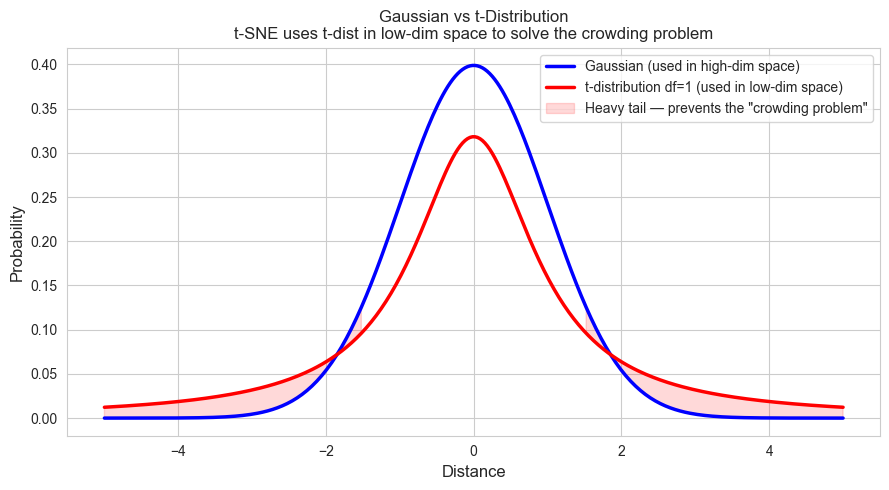

The t-distribution has a heavier tail → distant points can still be well separated!


In [3]:
# Illustrate the difference between Gaussian and t-distribution
from scipy.stats import norm, t as t_dist

x = np.linspace(-5, 5, 300)
gaussian = norm.pdf(x, 0, 1)
t1 = t_dist.pdf(x, df=1)  # t-distribution with 1 degree of freedom

plt.figure(figsize=(9, 5))
plt.plot(x, gaussian, 'b-', linewidth=2.5, label='Gaussian (used in high-dim space)')
plt.plot(x, t1,       'r-', linewidth=2.5, label='t-distribution df=1 (used in low-dim space)')
plt.fill_between(x, t1, gaussian, where=(np.abs(x) > 1.5), alpha=0.15, color='red',
                 label='Heavy tail — prevents the "crowding problem"')
plt.xlabel('Distance', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Gaussian vs t-Distribution\nt-SNE uses t-dist in low-dim space to solve the crowding problem',
          fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('The t-distribution has a heavier tail → distant points can still be well separated!')

Running t-SNE...
t-SNE completed in 0.78 seconds
Output shape: (150, 2)


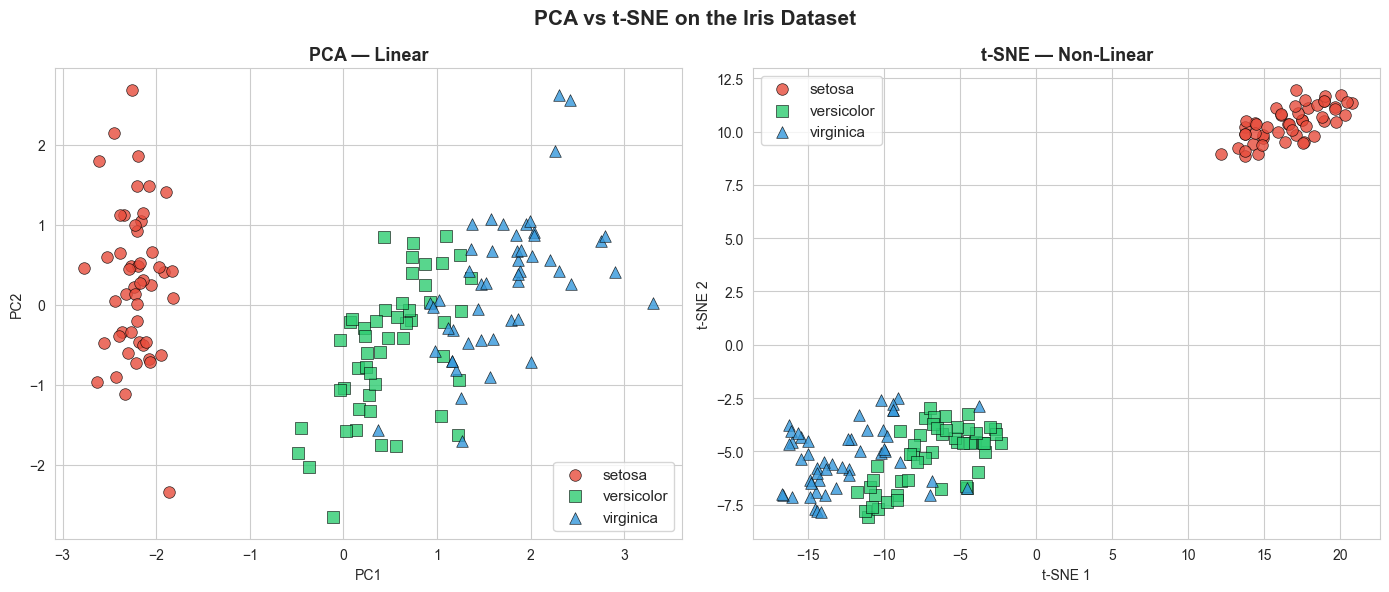

In [4]:
# Load and prepare data
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

# Standardize
X_scaled = StandardScaler().fit_transform(X_iris)

# Run t-SNE
print('Running t-SNE...')
start = time.time()
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
elapsed = time.time() - start
print(f't-SNE completed in {elapsed:.2f} seconds')
print(f'Output shape: {X_tsne.shape}')

# Side-by-side comparison with PCA
colors  = ['#e74c3c', '#2ecc71', '#3498db']
markers = ['o', 's', '^']

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, color, marker) in enumerate(zip(target_names, colors, markers)):
    idx = y_iris == i
    axes[0].scatter(X_pca[idx, 0],  X_pca[idx, 1],  c=color, marker=marker,
                    label=name, s=70, alpha=0.8, edgecolors='black', linewidth=0.5)
    axes[1].scatter(X_tsne[idx, 0], X_tsne[idx, 1], c=color, marker=marker,
                    label=name, s=70, alpha=0.8, edgecolors='black', linewidth=0.5)

axes[0].set_title('PCA — Linear', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=11)

axes[1].set_title('t-SNE — Non-Linear', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=11)

plt.suptitle('PCA vs t-SNE on the Iris Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]


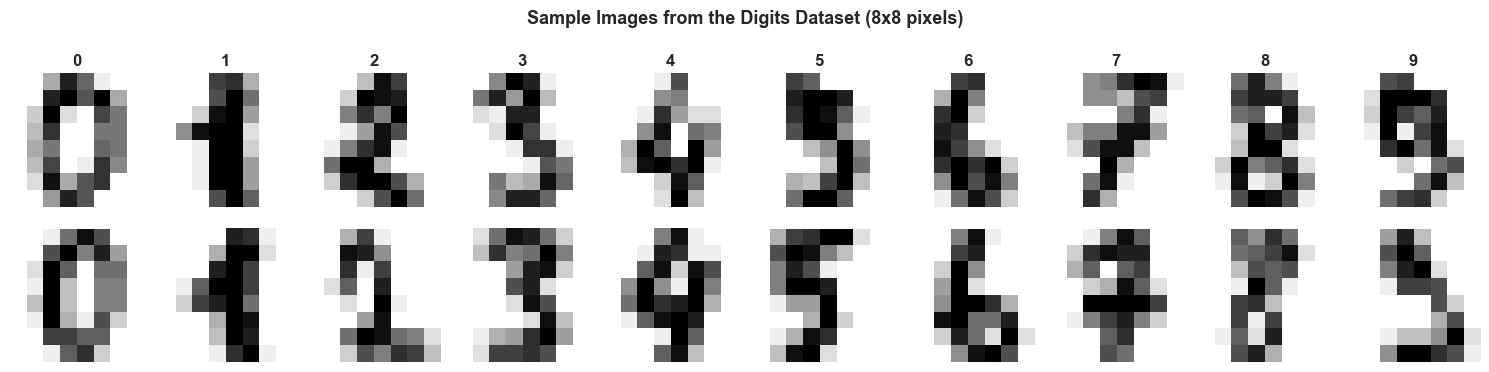

In [5]:
# Load Digits dataset
digits   = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f'Shape: {X_digits.shape}')       # (1797, 64)
print(f'Classes: {np.unique(y_digits)}')

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for digit in range(10):
    idx = np.where(y_digits == digit)[0][:2]
    for j, i in enumerate(idx):
        axes[j, digit].imshow(X_digits[i].reshape(8, 8), cmap='gray_r')
        axes[j, digit].axis('off')
        if j == 0:
            axes[j, digit].set_title(str(digit), fontsize=12, fontweight='bold')

plt.suptitle('Sample Images from the Digits Dataset (8x8 pixels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Step 1: Reduce to 50 components with PCA...
Step 2: Apply t-SNE to 2 dimensions...
Completed in 10.39 seconds


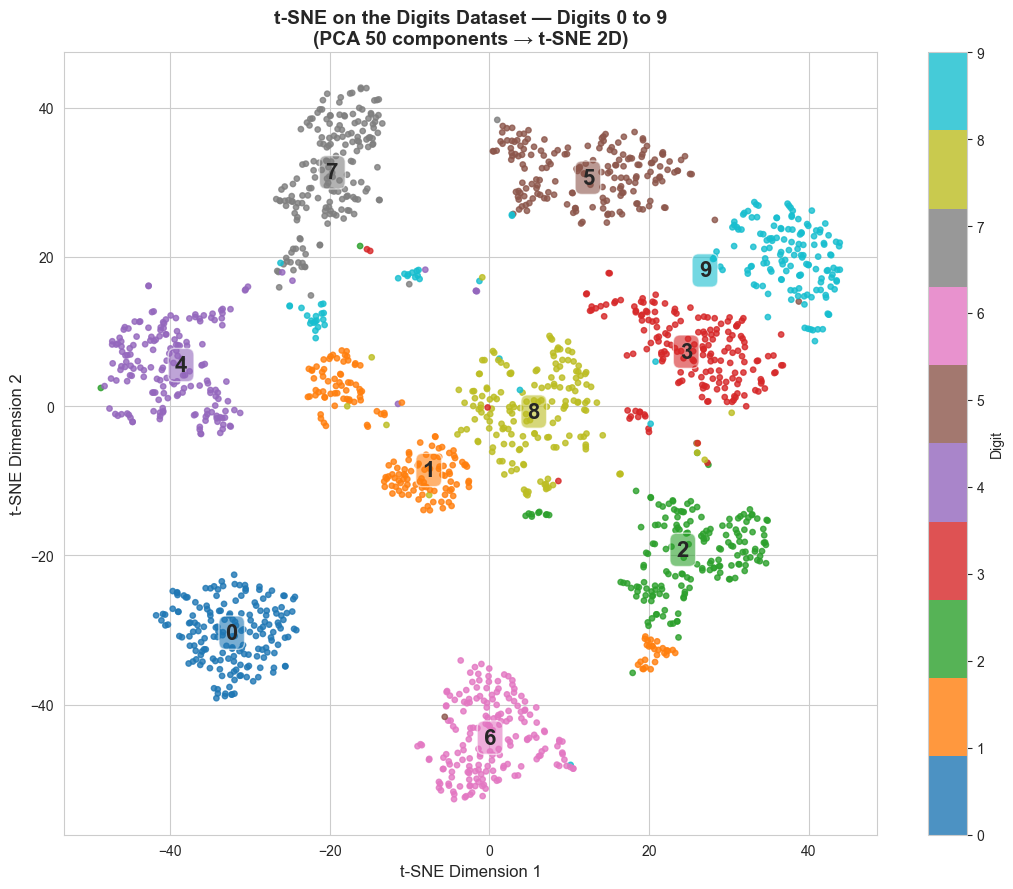

In [6]:
# t-SNE on Digits
X_digits_scaled = StandardScaler().fit_transform(X_digits)

# Best practice for large datasets: PCA first → then t-SNE
print('Step 1: Reduce to 50 components with PCA...')
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_digits_scaled)

print('Step 2: Apply t-SNE to 2 dimensions...')
start = time.time()
tsne_digits = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                   init='pca', n_iter=1000, random_state=42)
X_tsne_digits = tsne_digits.fit_transform(X_pca50)
print(f'Completed in {time.time()-start:.2f} seconds')

# Visualization with cluster labels
fig, ax = plt.subplots(figsize=(11, 9))
cmap    = plt.get_cmap('tab10')
scatter = ax.scatter(X_tsne_digits[:, 0], X_tsne_digits[:, 1],
                     c=y_digits, cmap='tab10', s=15, alpha=0.8)

# Add digit label at the center of each cluster
for digit in range(10):
    idx    = y_digits == digit
    center = X_tsne_digits[idx].mean(axis=0)
    ax.annotate(str(digit), center, fontsize=16, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=cmap(digit/10), alpha=0.6))

plt.colorbar(scatter, ax=ax, label='Digit', ticks=range(10))
ax.set_title('t-SNE on the Digits Dataset — Digits 0 to 9\n(PCA 50 components → t-SNE 2D)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
plt.tight_layout()
plt.show()

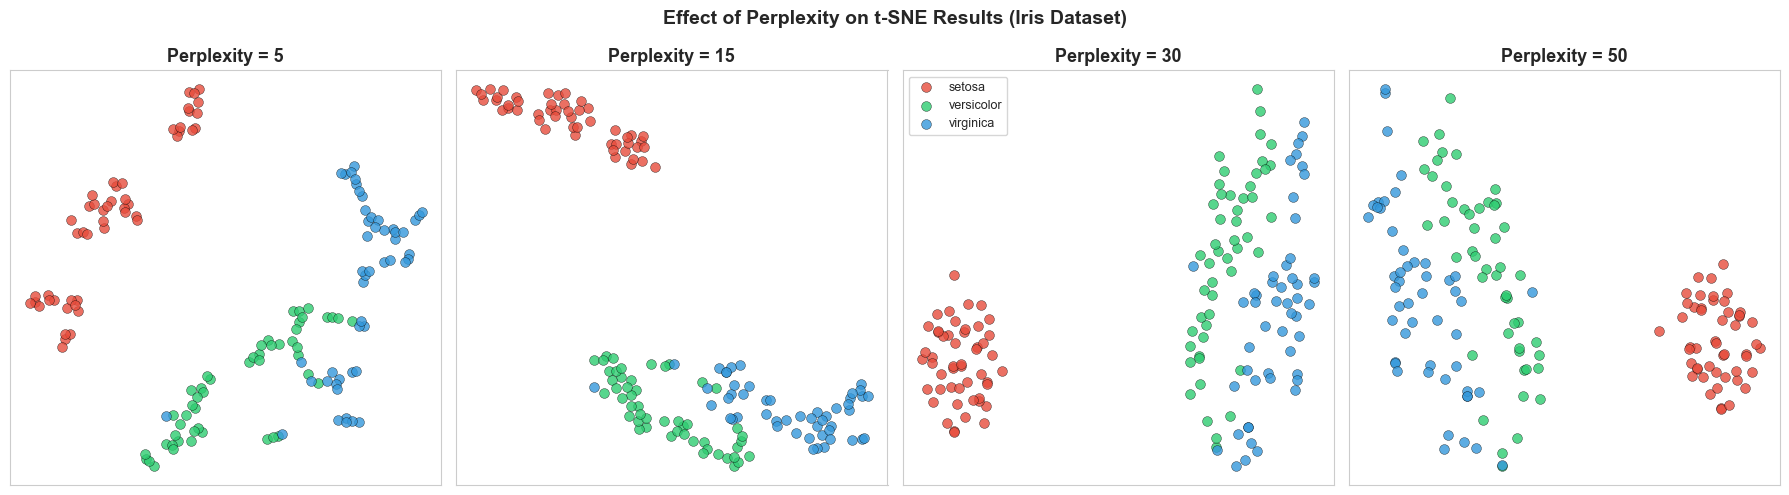

Perplexity = 5  : Very tight clusters, but highly fragmented
Perplexity = 50 : Clusters spread out, global structure more visible
Perplexity = 30 : Default — generally the best balance for most datasets


In [7]:
# Perplexity controls the balance between local and global structure.
# Low value  → focus on local neighborhoods
# High value → focus on global structure
# Recommended range: 5–50 (default: 30)

perplexities  = [5, 15, 30, 50]
X_iris_scaled = StandardScaler().fit_transform(X_iris)
colors_list   = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, perp in zip(axes, perplexities):
    tsne_temp = TSNE(n_components=2, perplexity=perp, n_iter=1000,
                     random_state=42, learning_rate='auto')
    X_temp = tsne_temp.fit_transform(X_iris_scaled)

    for i, (name, color) in enumerate(zip(target_names, colors_list)):
        idx = y_iris == i
        ax.scatter(X_temp[idx, 0], X_temp[idx, 1], c=color,
                   label=name, s=50, alpha=0.8, edgecolors='black', linewidth=0.3)

    ax.set_title(f'Perplexity = {perp}', fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if perp == 30:
        ax.legend(fontsize=9, loc='best')

plt.suptitle('Effect of Perplexity on t-SNE Results (Iris Dataset)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Perplexity = 5  : Very tight clusters, but highly fragmented')
print('Perplexity = 50 : Clusters spread out, global structure more visible')
print('Perplexity = 30 : Default — generally the best balance for most datasets')

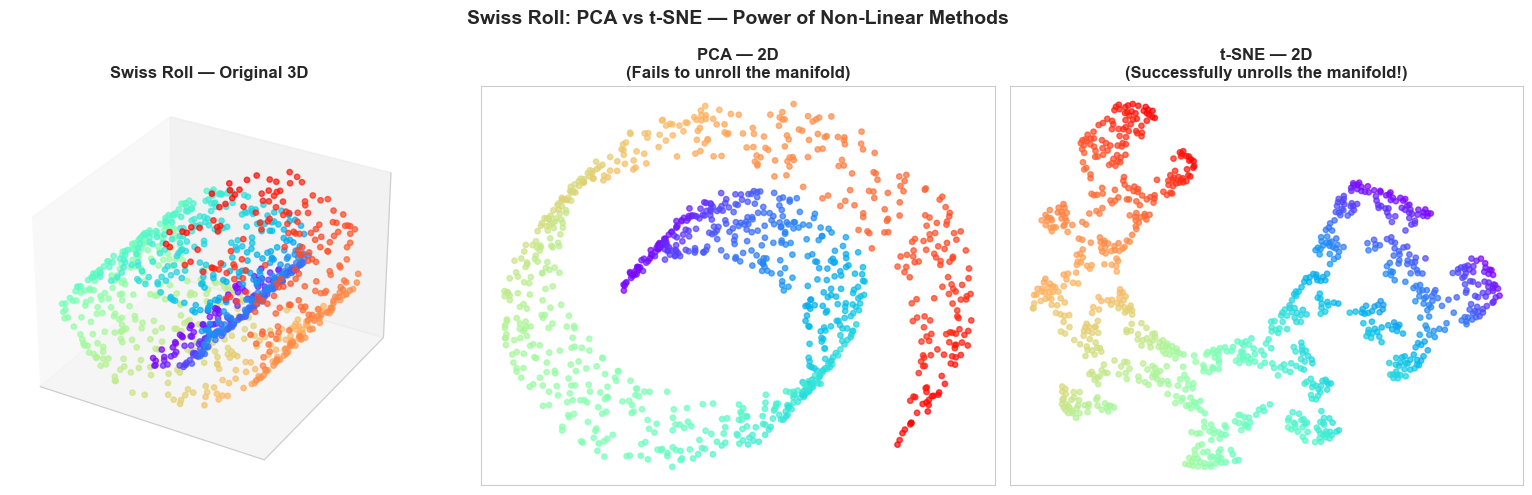

t-SNE successfully unrolls the Swiss Roll by capturing non-linear structure!
PCA fails because it can only capture linear relationships!


In [8]:
from mpl_toolkits.mplot3d import Axes3D

# Swiss Roll — a classic non-linear manifold dataset
X_roll, color_roll = make_swiss_roll(n_samples=1000, noise=0.1, random_state=42)

# PCA
X_roll_pca  = PCA(n_components=2).fit_transform(X_roll)

# t-SNE
X_roll_tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
                   random_state=42, learning_rate='auto').fit_transform(X_roll)

fig = plt.figure(figsize=(16, 5))

# 3D Original
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
            c=color_roll, cmap='rainbow', s=15, alpha=0.7)
ax1.set_title('Swiss Roll — Original 3D', fontsize=12, fontweight='bold')
ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

# PCA 2D
ax2 = fig.add_subplot(132)
ax2.scatter(X_roll_pca[:, 0], X_roll_pca[:, 1],
            c=color_roll, cmap='rainbow', s=15, alpha=0.7)
ax2.set_title('PCA — 2D\n(Fails to unroll the manifold)', fontsize=12, fontweight='bold')
ax2.set_xticks([]); ax2.set_yticks([])

# t-SNE 2D
ax3 = fig.add_subplot(133)
ax3.scatter(X_roll_tsne[:, 0], X_roll_tsne[:, 1],
            c=color_roll, cmap='rainbow', s=15, alpha=0.7)
ax3.set_title('t-SNE — 2D\n(Successfully unrolls the manifold!)', fontsize=12, fontweight='bold')
ax3.set_xticks([]); ax3.set_yticks([])

plt.suptitle('Swiss Roll: PCA vs t-SNE — Power of Non-Linear Methods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('t-SNE successfully unrolls the Swiss Roll by capturing non-linear structure!')
print('PCA fails because it can only capture linear relationships!')

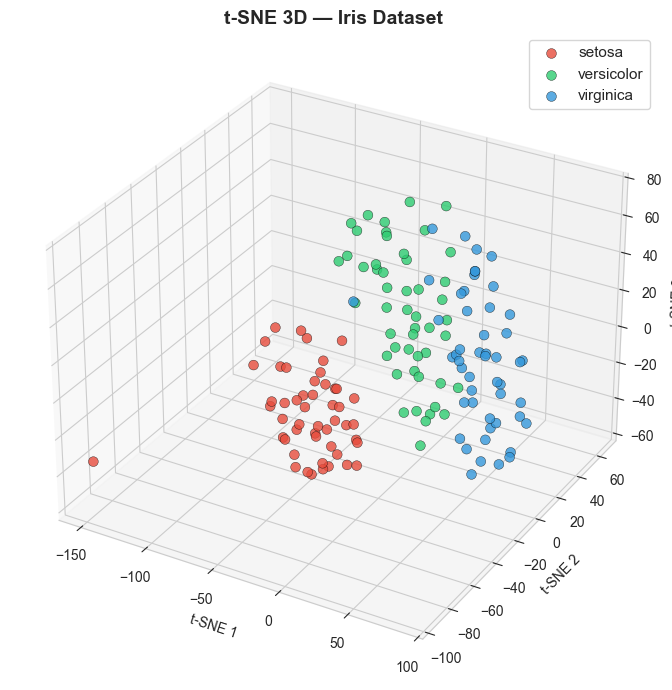

In [9]:
# t-SNE to 3 dimensions
X_iris_scaled = StandardScaler().fit_transform(X_iris)
tsne_3d       = TSNE(n_components=3, perplexity=30, n_iter=1000,
                     random_state=42, learning_rate='auto')
X_tsne_3d     = tsne_3d.fit_transform(X_iris_scaled)

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

colors_3d = ['#e74c3c', '#2ecc71', '#3498db']
for i, (name, color) in enumerate(zip(target_names, colors_3d)):
    idx = y_iris == i
    ax.scatter(X_tsne_3d[idx, 0], X_tsne_3d[idx, 1], X_tsne_3d[idx, 2],
               c=color, label=name, s=50, alpha=0.8,
               edgecolors='black', linewidth=0.3)

ax.set_xlabel('t-SNE 1', fontsize=10)
ax.set_ylabel('t-SNE 2', fontsize=10)
ax.set_zlabel('t-SNE 3', fontsize=10)
ax.set_title('t-SNE 3D — Iris Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Shape: (800, 50)


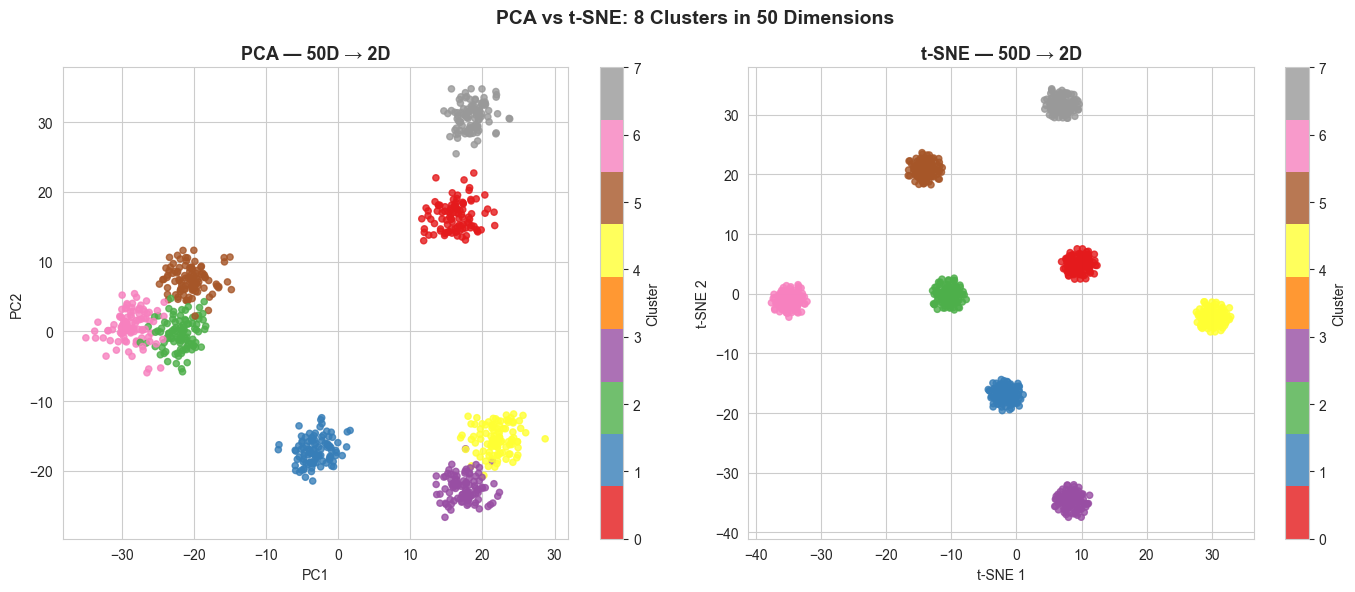

t-SNE separates clusters much more clearly than PCA!


In [10]:
# Create synthetic data with many clusters and high dimensions
X_blobs, y_blobs = make_blobs(n_samples=800, n_features=50,
                               centers=8, cluster_std=2.0, random_state=42)

print(f'Shape: {X_blobs.shape}')  # 800 samples, 50 features

# PCA
X_blobs_pca  = PCA(n_components=2, random_state=42).fit_transform(X_blobs)

# t-SNE
X_blobs_tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
                    random_state=42, learning_rate='auto').fit_transform(X_blobs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = 'Set1'

sc1 = axes[0].scatter(X_blobs_pca[:, 0],  X_blobs_pca[:, 1],
                       c=y_blobs, cmap=cmap, s=20, alpha=0.8)
axes[0].set_title('PCA — 50D → 2D', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_blobs_tsne[:, 0], X_blobs_tsne[:, 1],
                       c=y_blobs, cmap=cmap, s=20, alpha=0.8)
axes[1].set_title('t-SNE — 50D → 2D', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.suptitle('PCA vs t-SNE: 8 Clusters in 50 Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('t-SNE separates clusters much more clearly than PCA!')